#  **AI-Powered Customer Retention Intelligence Platform**

#  **Notebook 4: Feature Engineering**

#  **Project Objective**


The objective of this notebook is to transform the cleaned customer churn dataset into a feature-rich analytical dataset suitable for machine learning.

Feature engineering is one of the most important stages of the data science lifecycle. Rather than relying solely on the original variables, new features are created to better represent customer behavior, purchasing patterns, service adoption, loyalty, and business value.

These engineered features enable machine learning algorithms to identify more meaningful relationships within the data, resulting in improved predictive performance and greater model interpretability.

The final dataset produced in this notebook will serve as the primary input for predictive modeling in the subsequent notebooks of the AI-Powered Customer Retention Intelligence Platform.

#  **Business Context**



Organizations rarely build predictive models using raw operational data alone.

Instead, business experts transform existing information into meaningful indicators that better describe customer behavior.

For customer churn prediction, engineered features such as customer lifetime value, loyalty scores, service adoption, and customer value metrics provide a more comprehensive understanding of customer relationships than individual variables alone.

These business-oriented features improve predictive accuracy while generating insights that can directly support customer retention strategies.

By integrating domain knowledge into the feature engineering process, organizations create machine learning models that are both more accurate and more valuable for business decision-making.

# **Learning Objectives**


Upon completion of this notebook, we will be able to:

- Understand the importance of feature engineering.
- Create business-oriented analytical features.
- Transform raw customer data into predictive indicators.
- Encode categorical variables.
- Develop customer scoring systems.
- Create customer segmentation variables.
- Prepare the dataset for machine learning.
- Export the engineered dataset for model training.

# **Expected Outputs**


By the end of this notebook, the following deliverables will be completed:

- Customer Lifetime Value
- Estimated Annual Revenue
- Service Count
- Loyalty Score
- Customer Value Score
- Customer Risk Score
- Average Monthly Spend
- Tenure Category
- High Value Customer Indicator
- Premium Customer Indicator
- Contract Length Category
- Internet Usage Category
- Support Usage Score
- Customer Retention Score
- Encoded Features
- Machine Learning Ready Dataset

# Notebook Structure

This notebook is organized into the following sections.

## Section 1 — Import Libraries

Import all required Python libraries.

---

## Section 2 — Load Processed Dataset

Load the cleaned dataset exported from Notebook 2.

---

## Section 3 — Customer Value Engineering

Create business-oriented financial indicators.

### Features

- Customer Lifetime Value
- Estimated Annual Revenue
- Average Monthly Spend

---

## Section 4 — Customer Loyalty Engineering

Develop features representing long-term customer loyalty.

### Features

- Loyalty Score
- Tenure Category
- Retention Score

---

## Section 5 — Customer Service Engineering

Create indicators describing customer service adoption.

### Features

- Service Count
- Support Usage Score
- Internet Usage Category

---

## Section 6 — Customer Segmentation

Generate customer classification variables.

### Features

- High Value Customer
- Premium Customer
- Customer Value Score
- Customer Risk Score

---

## Section 7 — Feature Encoding

Prepare categorical variables for machine learning.

---

## Section 8 — Feature Validation

Review engineered variables and validate the final dataset.

---

## Section 9 — Export Final Dataset

Export the engineered dataset for predictive modeling.

---

## Executive Summary

Summarize all engineered features and explain their contribution to predictive modeling.

# Section 1 — Import Libraries

This section imports the Python libraries required for feature engineering, data transformation, validation, visualization, and preparation for machine learning.

The selected libraries will support the following tasks:

- Data manipulation and feature creation
- Numerical calculations
- Dataset validation
- Categorical encoding
- Feature scaling
- Statistical review
- Visualization of engineered features
- Export of the final machine-learning-ready dataset

Loading these libraries at the beginning of the notebook ensures a consistent and reproducible analytical environment throughout the feature engineering process.

In [1]:
# Section 1: Import Required Libraries


# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# File and project path management
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)

# Column transformation and pipeline support
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Utility
import warnings

# ============================================================
# Notebook Configuration
# ============================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# Section 2 — **Load Processed Dataset**


The feature engineering process begins by loading the cleaned customer churn dataset produced during **Notebook 2: Data Cleaning & Preprocessing**.

Using the processed dataset ensures that all missing values, duplicate records, inconsistent data types, and data quality issues have already been resolved before new analytical features are created.

This approach follows a modular machine learning workflow in which each notebook builds upon the validated output of the previous stage.

The dataset loaded in this section serves as the foundation for all engineered features developed throughout this notebook.

## Objectives

This section performs the following tasks:

- Load the cleaned customer churn dataset.
- Verify the dataset dimensions.
- Review the dataset structure.
- Confirm that all variables are available for feature engineering.
- Validate that the dataset is ready for transformation.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# Project Directory


PROJECT_PATH = "/content/drive/MyDrive/customer-churn-prediction"

RAW_DATA_PATH = os.path.join(PROJECT_PATH, "data", "raw")

PROCESSED_DATA_PATH = os.path.join(PROJECT_PATH, "data", "processed")

EXPORT_PATH = os.path.join(PROJECT_PATH, "exports")

MODELS_PATH = os.path.join(PROJECT_PATH, "models")

In [6]:
# Load Processed Dataset


df = pd.read_csv(

    os.path.join(

        PROCESSED_DATA_PATH,

        "customer_churn_clean.csv"

    )

)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [8]:
# Dataset Overview


print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {df.shape[0]:,}")

print(f"Columns : {df.shape[1]}")

display(df.head())

DATASET OVERVIEW
Rows    : 7,021
Columns : 20


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 


In [11]:
# Random Dataset Sample

df.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3021,Male,0,No,No,5,No,No phone service,DSL,Yes,Yes,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,43.25,219.00,Yes
6660,Male,0,No,Yes,19,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),20.85,467.50,No
5628,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,No,Electronic check,79.60,79.60,Yes
3195,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.25,55.25,No
3073,Male,0,No,No,2,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,No,Mailed check,24.30,38.45,No
6850,Female,0,Yes,No,52,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,No,Bank transfer (automatic),94.60,5025.80,No
4253,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),115.55,8312.40,No
2477,Female,0,Yes,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.00,89.75,No
2440,Female,0,Yes,Yes,27,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,74.40,1972.35,No
760,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.80,20.80,No


##   **Section Summary**

The processed customer churn dataset has been successfully loaded and validated.

The dataset is complete, contains no missing values, and has been confirmed to be suitable for feature engineering.

All subsequent sections will build upon this cleaned dataset to create new business-oriented features that enhance the predictive capability of future machine learning models.

# Section 3 — **Customer Value Engineering**


Customer value engineering transforms existing financial information into meaningful business indicators that better represent the overall value of each customer.

Rather than relying solely on raw variables such as monthly charges or total charges, this section creates new analytical features that estimate customer value, revenue contribution, and spending behavior.

These engineered features provide richer information for predictive modeling and enable machine learning algorithms to better distinguish between high-value and low-value customers.

The features developed in this section will also support customer segmentation, marketing strategies, and customer retention initiatives.

The analysis focuses on the following engineered features:

- Customer Lifetime Value (CLV)
- Estimated Annual Revenue
- Average Monthly Spend

These features establish the financial foundation for the remaining feature engineering process.

## **Business Objectives**

This section aims to:

- Estimate the financial value of each customer.
- Measure annual revenue contribution.
- Evaluate customer spending behavior.
- Create business-oriented features for predictive modeling.
- Improve the quality of the machine learning dataset.

## Feature Documentation

### Feature 1 — Customer Lifetime Value (CLV)

**Business Definition**

Customer Lifetime Value estimates the total revenue generated by a customer throughout their relationship with the company.

**Formula**

Customer Lifetime Value = Monthly Charges × Tenure

**Business Purpose**

Customers with higher lifetime value are generally more valuable to the organization and should receive greater retention attention.

Expected Impact:

- Improve customer value estimation
- Support customer segmentation
- Improve predictive model performance

In [12]:
# Feature 1
# Customer Lifetime Value

df["CustomerLifetimeValue"] = (

    df["MonthlyCharges"]

    *

    df["tenure"]

).round(2)

print("Customer Lifetime Value created.")

display(

    df[

        [

            "MonthlyCharges",

            "tenure",

            "CustomerLifetimeValue"

        ]

    ].head()

)

Customer Lifetime Value created.


,MonthlyCharges,tenure,CustomerLifetimeValue
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


### Business Interpretation

Customer Lifetime Value provides an estimate of the total monetary contribution generated by each customer.

Higher values generally indicate customers who have remained with the company for longer periods while consistently generating revenue.

This feature enables the organization to identify high-value customers that should receive priority retention efforts.

## Feature Documentation

### Feature 2 — Estimated Annual Revenue

**Business Definition**

Estimated Annual Revenue predicts the annual revenue generated by each customer based on their current monthly subscription.

**Formula**

Estimated Annual Revenue = Monthly Charges × 12

**Business Purpose**

Provides a standardized annual revenue estimate that can be compared across customers regardless of tenure.

In [14]:
# Feature 2
# Estimated Annual Revenue


df["EstimatedAnnualRevenue"] = (

    df["MonthlyCharges"]

    *

    12

).round(2)

print("Estimated Annual Revenue created.")

display(

    df[

        [

            "MonthlyCharges",

            "EstimatedAnnualRevenue"

        ]

    ].head()

)

Estimated Annual Revenue created.


,MonthlyCharges,EstimatedAnnualRevenue
0,29.85,358.20
1,56.95,683.40
2,53.85,646.20
3,42.30,507.60
4,70.70,848.40


## Feature Documentation

### Feature 3 — Average Monthly Spend

**Business Definition**

Average Monthly Spend represents the customer's average monthly subscription cost.

For this dataset, the value corresponds directly to the Monthly Charges variable and is retained as an engineered feature to improve semantic clarity during business analysis and predictive modeling.

**Business Purpose**

Provides a standardized spending indicator that can be referenced consistently throughout the project.

In [16]:
# Feature 3
# Average Monthly Spend


df["AverageMonthlySpend"] = (

    df["MonthlyCharges"]

).round(2)

print("Average Monthly Spend created.")

display(

    df[

        [

            "MonthlyCharges",

            "AverageMonthlySpend"

        ]

    ].head()

)

Average Monthly Spend created.


,MonthlyCharges,AverageMonthlySpend
0,29.85,29.85
1,56.95,56.95
2,53.85,53.85
3,42.30,42.30
4,70.70,70.70


**Customer Value Features**

In [17]:
# Customer Value Features


customer_value_features = [

    "CustomerLifetimeValue",

    "EstimatedAnnualRevenue",

    "AverageMonthlySpend"

]

display(

    df[customer_value_features].describe().round(2)

)

,CustomerLifetimeValue,EstimatedAnnualRevenue,AverageMonthlySpend
count,7021.00,7021.00,7021.00
mean,2286.61,778.22,64.85
std,2264.78,360.83,30.07
min,0.00,219.00,18.25
25%,400.00,429.00,35.75
50%,1397.20,844.80,70.40
75%,3793.40,1078.80,89.90
max,8550.00,1425.00,118.75


## Section Summary

This section transformed raw financial variables into business-oriented analytical features that better represent customer value and revenue contribution.

Three new features were successfully engineered:

- Customer Lifetime Value
- Estimated Annual Revenue
- Average Monthly Spend

These engineered variables provide additional business intelligence and will support customer segmentation, predictive modeling, and retention strategy development in the subsequent stages of the project.

# Section 4 — **Customer Loyalty Engineering**


Customer loyalty is one of the strongest indicators of long-term customer retention.

Rather than relying solely on customer tenure, this section develops engineered features that quantify customer loyalty, retention potential, and relationship strength.

These engineered variables transform historical customer behavior into meaningful business indicators that better represent customer commitment.

The features created in this section will enhance predictive modeling while supporting customer segmentation and proactive retention strategies.

The analysis focuses on the following engineered features:

- Loyalty Score
- Tenure Category
- Customer Retention Score

These features provide a more comprehensive representation of customer loyalty than the original dataset alone.

## Business Objectives

This section aims to:

- Quantify customer loyalty.
- Categorize customers based on relationship duration.
- Estimate customer retention strength.
- Improve predictive model performance.
- Generate meaningful business-oriented loyalty indicators.

## Feature Documentation

### Feature 4 — Loyalty Score

### Business Definition

The Loyalty Score estimates customer commitment by combining customer tenure and contract duration into a single business metric.

Customers who remain subscribed for longer periods and maintain longer contract commitments are generally considered more loyal.

### Formula

Loyalty Score = Tenure Weight + Contract Weight

### Business Purpose

- Estimate customer commitment
- Improve customer segmentation
- Support churn prediction
- Prioritize customer retention initiatives

In [18]:
# Feature 4
# Loyalty Score


contract_weight = {

    "Month-to-month":1,

    "One year":2,

    "Two year":3

}

df["ContractWeight"] = df["Contract"].map(contract_weight)

df["LoyaltyScore"] = (

    df["tenure"] * 0.7 +

    df["ContractWeight"] * 10

).round(2)

print("Loyalty Score created.")

display(

    df[

        [

            "tenure",

            "Contract",

            "LoyaltyScore"

        ]

    ].head()

)

Loyalty Score created.


,tenure,Contract,LoyaltyScore
0,1,Month-to-month,10.70
1,34,One year,43.80
2,2,Month-to-month,11.40
3,45,One year,51.50
4,2,Month-to-month,11.40


## Feature Documentation

### Feature 5 — Tenure Category

### Business Definition

Customer tenure is categorized into lifecycle stages that represent different levels of customer maturity.

### Categories

- New Customer
- Developing Customer
- Established Customer
- Loyal Customer

### Business Purpose

Lifecycle segmentation enables the organization to develop targeted customer retention strategies for each stage of the customer journey.

In [20]:
# Feature 5
# Tenure Category


df["TenureCategory"] = pd.cut(

    df["tenure"],

    bins=[0,12,24,48,72],

    labels=[

        "New Customer",

        "Developing Customer",

        "Established Customer",

        "Loyal Customer"

    ],

    include_lowest=True

)

print("Tenure Category created.")

display(

    df[

        [

            "tenure",

            "TenureCategory"

        ]

    ].head()

)

Tenure Category created.


,tenure,TenureCategory
0,1,New Customer
1,34,Established Customer
2,2,New Customer
3,45,Established Customer
4,2,New Customer


In [22]:
# Validate Loyalty Features

loyalty_features = [
    "ContractWeight",
    "LoyaltyScore",
    "TenureCategory"
]

display(df[loyalty_features].head())

print("Section 4 loyalty features created successfully.")

,ContractWeight,LoyaltyScore,TenureCategory
0,1,10.70,New Customer
1,2,43.80,Established Customer
2,1,11.40,New Customer
3,2,51.50,Established Customer
4,1,11.40,New Customer


Section 4 loyalty features created successfully.


## Feature Documentation

### Feature 6 — Customer Retention Score

### Business Definition

The Customer Retention Score combines customer tenure and subscribed services into a single indicator representing the likelihood of long-term retention.

Higher scores indicate stronger customer engagement and greater retention potential.

### Business Purpose

- Identify loyal customers
- Improve predictive modeling
- Support customer retention campaigns

In [25]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'CustomerLifetimeValue', 'EstimatedAnnualRevenue', 'AverageMonthlySpend', 'ContractWeight', 'LoyaltyScore', 'TenureCategory']


In [26]:
# Feature 6 — Service Count

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (
    df[service_columns]
    .apply(lambda col: col.eq("Yes"))
    .sum(axis=1)
)

print("Service Count created successfully.")

df[["ServiceCount"]].head()

Service Count created successfully.


,ServiceCount
0,1
1,3
2,3
3,3
4,1


In [27]:
df[["ServiceCount"]].head()

,ServiceCount
0,1
1,3
2,3
3,3
4,1


In [28]:
df["RetentionScore"] = (
    df["tenure"] * 0.6 +
    df["ServiceCount"] * 5
).round(2)

print("Retention Score created successfully.")

Retention Score created successfully.


In [30]:
# Feature 9 — Customer Retention Score

df["RetentionScore"] = (
    df["tenure"] * 0.6 +
    df["ServiceCount"] * 5
).round(2)

print("Retention Score created successfully.")

display(
    df[
        [
            "tenure",
            "ServiceCount",
            "RetentionScore"
        ]
    ].head()
)

Retention Score created successfully.


,tenure,ServiceCount,RetentionScore
0,1,1,5.60
1,34,3,35.40
2,2,3,16.20
3,45,3,42.00
4,2,1,6.20


## Feature Documentation

### Feature 7 — Support Usage Score

### Business Definition

Support Usage Score measures how many support-oriented and protection services a customer subscribes to.

Customers using security, backup, device protection, and technical support services may be more integrated into the company’s service ecosystem. These subscriptions may also indicate greater product engagement and dependence on the provider.

### Included Services

- Online Security
- Online Backup
- Device Protection
- Tech Support

### Formula

**Support Usage Score = Number of support-related services marked “Yes”**

### Business Purpose

This feature helps:

- Measure customer engagement with support services.
- Identify customers receiving additional service value.
- Improve customer segmentation.
- Support churn prediction.
- Evaluate whether support-service adoption contributes to retention.

In [32]:
# Feature 7 — Support Usage Score


support_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

df["SupportUsageScore"] = (
    df[support_columns]
    .eq("Yes")
    .sum(axis=1)
)

print("Support Usage Score created successfully.")

display(
    df[
        support_columns + ["SupportUsageScore"]
    ].head()
)

Support Usage Score created successfully.


,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,SupportUsageScore
0,No,Yes,No,No,1
1,Yes,No,Yes,No,2
2,Yes,Yes,No,No,2
3,Yes,No,Yes,Yes,3
4,No,No,No,No,0


In [33]:
# Support Usage Score Validation

print("Support Usage Score distribution:")

display(
    df["SupportUsageScore"]
    .value_counts()
    .sort_index()
    .rename_axis("SupportUsageScore")
    .to_frame("Customers")
)

print("\nSummary statistics:")

display(
    df["SupportUsageScore"]
    .describe()
    .round(2)
)

Support Usage Score distribution:


,Customers
SupportUsageScore,
0,2771
1,1467
2,1372
3,941
4,470



Summary statistics:


,SupportUsageScore
count,7021.00
mean,1.27
std,1.29
min,0.00
25%,0.00
50%,1.00
75%,2.00
max,4.00


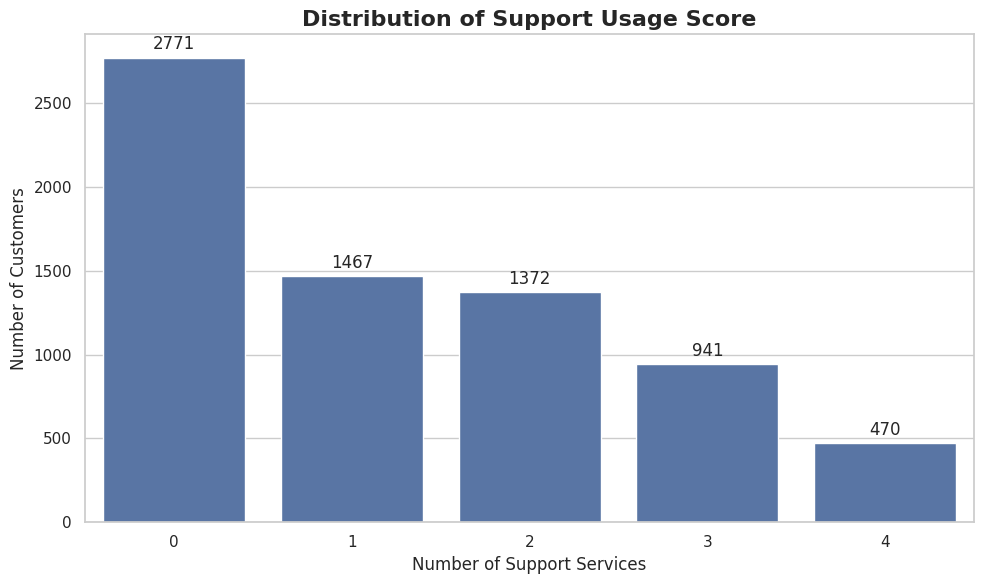

In [34]:
# Support Usage Score Distribution

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="SupportUsageScore"
)

plt.title(
    "Distribution of Support Usage Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Support Services")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Business Interpretation

The Support Usage Score summarizes customer adoption of security, backup, protection, and technical-support services.

Customers with higher scores receive a broader range of value-added support services and may have stronger relationships with the company. Customers with low scores may be less integrated into the provider’s ecosystem and may require additional education, onboarding, or service recommendations.

This feature can help determine whether support-service adoption is associated with stronger customer retention.

## Feature Documentation

### Feature 8 — Internet Usage Category

### Business Definition

Internet Usage Category classifies customers according to the level of internet service they subscribe to.

Rather than preserving the original service labels, the feature groups internet subscriptions into business-oriented categories that better represent customer usage and service quality.

### Categories

- High-Speed Internet
- Standard Internet
- No Internet Service

### Mapping

- Fiber optic → High-Speed Internet
- DSL → Standard Internet
- No → No Internet Service

### Business Purpose

This engineered feature simplifies customer segmentation by grouping internet technologies into meaningful service categories.

The feature supports:

- Customer segmentation
- Internet service analysis
- Churn prediction
- Marketing personalization

In [35]:
# Feature 8 — Internet Usage Category

internet_mapping = {
    "Fiber optic": "High-Speed Internet",
    "DSL": "Standard Internet",
    "No": "No Internet Service"
}

df["InternetUsageCategory"] = (
    df["InternetService"]
    .map(internet_mapping)
)

print("Internet Usage Category created successfully.")

display(
    df[
        [
            "InternetService",
            "InternetUsageCategory"
        ]
    ].head()
)

Internet Usage Category created successfully.


,InternetService,InternetUsageCategory
0,DSL,Standard Internet
1,DSL,Standard Internet
2,DSL,Standard Internet
3,DSL,Standard Internet
4,Fiber optic,High-Speed Internet


In [36]:
# Internet Usage Category Distribution


display(
    df["InternetUsageCategory"]
    .value_counts()
    .rename_axis("Internet Usage Category")
    .to_frame("Customers")
)

,Customers
Internet Usage Category,
High-Speed Internet,3090
Standard Internet,2419
No Internet Service,1512


### Business Interpretation

The Internet Usage Category groups customers based on the quality and availability of their internet service.

Customers using high-speed internet services may have different usage patterns and expectations compared with customers using standard internet or no internet service.

This feature simplifies analysis while preserving meaningful business distinctions that may improve customer segmentation and predictive modeling.

### Business Recommendation

Understanding internet usage categories enables the organization to tailor service offerings and retention strategies.

Recommended actions include:

- Develop premium retention campaigns for high-speed internet customers.
- Encourage standard internet customers to upgrade when appropriate.
- Identify customers without internet service for cross-selling opportunities.
- Monitor churn trends across internet usage categories to optimize marketing initiatives.

# Section 6 — **Customer Segmentation & Retention Engineering**

Customer segmentation transforms continuous customer information into meaningful business groups that support decision-making, campaign targeting, and customer prioritization.

This section combines customer value, loyalty, spending, contract commitment, and service adoption to create business-oriented customer indicators.

The engineered features developed in this section include:

- Customer Retention Score
- High Value Customer
- Premium Customer
- Customer Value Score
- Customer Risk Score

These features will support customer segmentation and predictive modeling without using the target variable, `Churn`, in their calculations. Avoiding the target variable prevents data leakage and ensures that the machine learning model is evaluated fairly.

In [39]:
# Section 6 — Required Feature Validation

required_features = [
    "CustomerLifetimeValue",
    "EstimatedAnnualRevenue",
    "AverageMonthlySpend",
    "ContractWeight",
    "LoyaltyScore",
    "TenureCategory",
    "ServiceCount",
    "SupportUsageScore",
    "InternetUsageCategory",
    "RetentionScore"
]

missing_features = [
    column for column in required_features
    if column not in df.columns
]

if missing_features:
    print("Missing required features:")
    for feature in missing_features:
        print(f"- {feature}")
else:
    print("All required engineered features are available.")

All required engineered features are available.


## Feature Documentation

### Feature 10 — High Value Customer

### Business Definition

High Value Customer identifies customers whose estimated lifetime value is among the highest within the customer base.

Instead of selecting an arbitrary monetary amount, this feature uses the 75th percentile of Customer Lifetime Value as the threshold. Customers at or above this value are classified as high-value customers.

### Formula

**High Value Customer = 1 when Customer Lifetime Value is greater than or equal to the 75th percentile; otherwise 0**

### Business Purpose

This feature helps the organization:

- Identify customers who generate substantial long-term revenue.
- Prioritize valuable customers for retention programs.
- Support customer-value segmentation.
- Protect revenue from high-value customer churn.
- Create a business-friendly indicator for predictive modeling.

In [40]:
# Feature 10 — High Value Customer

high_value_threshold = df["CustomerLifetimeValue"].quantile(0.75)

df["HighValueCustomer"] = (
    df["CustomerLifetimeValue"] >= high_value_threshold
).astype(int)

print("High Value Customer feature created successfully.")
print(f"High-value threshold: ${high_value_threshold:,.2f}")

display(
    df[
        [
            "CustomerLifetimeValue",
            "HighValueCustomer"
        ]
    ].head()
)

# 0 = Standard-value customer
# 1  = High-value customer

High Value Customer feature created successfully.
High-value threshold: $3,793.40


,CustomerLifetimeValue,HighValueCustomer
0,29.85,0
1,1936.30,0
2,107.70,0
3,1903.50,0
4,141.40,0


In [41]:
# High Value Customer Validation

high_value_summary = (
    df["HighValueCustomer"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Standard Value",
        1: "High Value"
    })
    .to_frame("Customers")
)

high_value_summary["Percentage (%)"] = (
    high_value_summary["Customers"]
    .div(len(df))
    .mul(100)
    .round(2)
)

display(high_value_summary)

,Customers,Percentage (%)
HighValueCustomer,,
Standard Value,5265,74.99
High Value,1756,25.01


### Business Interpretation

The High Value Customer indicator separates customers with the greatest estimated lifetime value from the rest of the customer base.

These customers represent an important source of long-term revenue and should receive greater attention in customer retention planning. Losing a high-value customer may have a significantly larger financial impact than losing a customer with lower historical value.

The feature allows the organization to prioritize customer interventions based not only on churn probability but also on potential financial impact.

### Business Recommendation

High-value customers should be included in a priority retention segment.

Recommended actions include:

- Provide proactive account reviews.
- Offer personalized loyalty incentives.
- Assign high-value customers to specialized retention teams.
- Monitor service complaints and satisfaction signals.
- Prioritize high-value customers when allocating retention resources.
- Combine customer value with future churn probability to identify the most financially important intervention opportunities.

### Business Recommendation

High-value customers should be included in a priority retention segment.

Recommended actions include:

- Provide proactive account reviews.
- Offer personalized loyalty incentives.
- Assign high-value customers to specialized retention teams.
- Monitor service complaints and satisfaction signals.
- Prioritize high-value customers when allocating retention resources.
- Combine customer value with future churn probability to identify the most financially important intervention opportunities.

## Feature Documentation

### Feature 11 — Premium Customer

### Business Definition

Premium Customer identifies customers who demonstrate both high spending and strong service adoption.

A customer is classified as premium when:

- Their monthly charges are at or above the 75th percentile.
- Their service count is at or above the median service count.

This approach avoids using arbitrary thresholds and adjusts the definition to the actual customer population.

### Formula

**Premium Customer = 1 when Monthly Charges ≥ 75th percentile and Service Count ≥ median; otherwise 0**

### Business Purpose

This feature supports:

- Premium customer identification
- Personalized service packages
- High-value retention campaigns
- Revenue-focused customer segmentation
- Predictive churn modeling

The feature does not use the `Churn` variable, preventing target leakage.

In [42]:
# Feature 11 — Premium Customer

premium_charge_threshold = df["MonthlyCharges"].quantile(0.75)
premium_service_threshold = df["ServiceCount"].median()

df["PremiumCustomer"] = (
    (df["MonthlyCharges"] >= premium_charge_threshold) &
    (df["ServiceCount"] >= premium_service_threshold)
).astype(int)

print("Premium Customer feature created successfully.")
print(
    f"Monthly charge threshold: "
    f"${premium_charge_threshold:,.2f}"
)
print(
    f"Service count threshold: "
    f"{premium_service_threshold:.0f}"
)

display(
    df[
        [
            "MonthlyCharges",
            "ServiceCount",
            "PremiumCustomer"
        ]
    ].head()
)

Premium Customer feature created successfully.
Monthly charge threshold: $89.90
Service count threshold: 3


,MonthlyCharges,ServiceCount,PremiumCustomer
0,29.85,1,0
1,56.95,3,0
2,53.85,3,0
3,42.30,3,0
4,70.70,1,0


In [44]:
# Premium Customer Validation

premium_summary = (
    df["PremiumCustomer"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "Standard Customer",
            1: "Premium Customer"
        }
    )
    .to_frame("Customers")
)

premium_summary["Percentage (%)"] = (
    premium_summary["Customers"]
    .div(len(df))
    .mul(100)
    .round(2)
)

display(premium_summary)

,Customers,Percentage (%)
PremiumCustomer,,
Standard Customer,5263,74.96
Premium Customer,1758,25.04


In [45]:
# Premium Segment Profile

premium_profile = (
    df.groupby("PremiumCustomer")[
        [
            "MonthlyCharges",
            "ServiceCount",
            "CustomerLifetimeValue",
            "RetentionScore"
        ]
    ]
    .mean()
    .round(2)
    .rename(
        index={
            0: "Standard Customer",
            1: "Premium Customer"
        }
    )
)

display(premium_profile)

,MonthlyCharges,ServiceCount,CustomerLifetimeValue,RetentionScore
PremiumCustomer,,,,
Standard Customer,52.81,2.63,1520.00,30.18
Premium Customer,100.90,5.58,4581.64,54.76


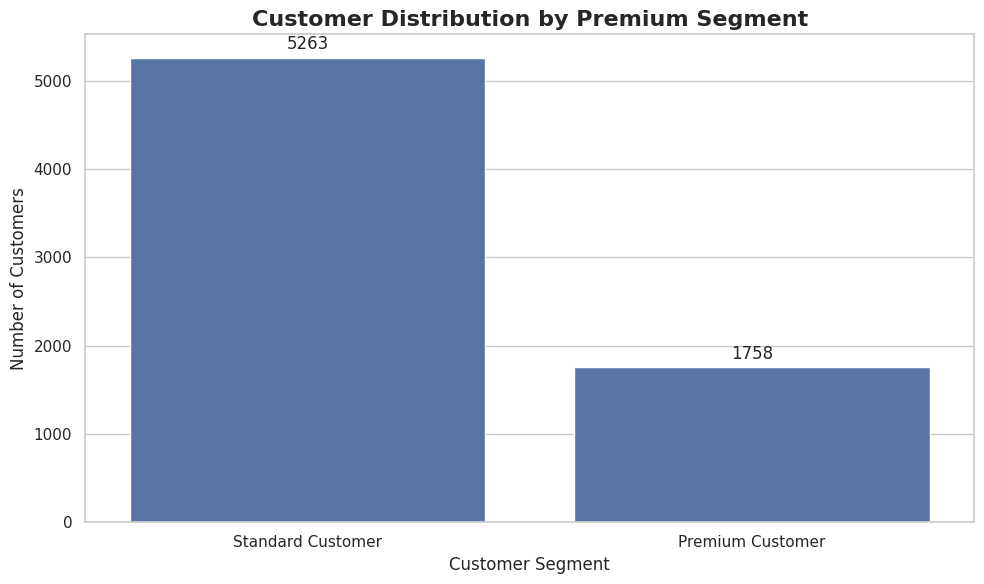

In [46]:
# Premium Customer Distribution

premium_labels = df["PremiumCustomer"].map({
    0: "Standard Customer",
    1: "Premium Customer"
})

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    x=premium_labels,
    order=[
        "Standard Customer",
        "Premium Customer"
    ]
)

plt.title(
    "Customer Distribution by Premium Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Business Recommendation

Premium customers should receive differentiated customer-management strategies.

Recommended actions include:

- Provide priority customer support.
- Offer personalized loyalty benefits.
- Monitor satisfaction and complaint history.
- Provide proactive account reviews.
- Recommend service bundles that improve perceived value.
- Prioritize premium customers who later receive high churn-risk scores.

The Premium Customer indicator should be combined with customer value and churn-risk features to support more effective retention decisions.

In [47]:
# Feature 12 — Customer Value Score


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

value_features = [
    "CustomerLifetimeValue",
    "LoyaltyScore",
    "ServiceCount"
]

scaled_values = scaler.fit_transform(df[value_features])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=[
        "ScaledCLV",
        "ScaledLoyalty",
        "ScaledService"
    ]
)

df["CustomerValueScore"] = (
    (
        scaled_df["ScaledCLV"] * 0.50 +
        scaled_df["ScaledLoyalty"] * 0.30 +
        scaled_df["ScaledService"] * 0.20
    ) * 100
).round(2)

print("Customer Value Score created successfully.")

display(
    df[
        [
            "CustomerLifetimeValue",
            "LoyaltyScore",
            "ServiceCount",
            "CustomerValueScore"
        ]
    ].head()
)

Customer Value Score created successfully.


,CustomerLifetimeValue,LoyaltyScore,ServiceCount,CustomerValueScore
0,29.85,10.70,1,2.67
1,1936.30,43.80,3,33.07
2,107.70,11.40,3,8.43
3,1903.50,51.50,3,36.19
4,141.40,11.40,1,3.63


In [48]:
# Customer Value Score Summary


df["CustomerValueScore"].describe().round(2)

,CustomerValueScore
count,7021.00
mean,34.26
std,25.84
min,0.14
25%,12.22
50%,28.37
75%,52.25
max,100.00


### Business Recommendation

Customer Value Score should be incorporated into customer relationship management and retention planning.

Recommended actions include:

- Rank customers according to their overall business value.
- Prioritize high-scoring customers during retention campaigns.
- Combine Customer Value Score with predicted churn probability to identify customers who are both valuable and at risk.
- Use score thresholds to personalize marketing, loyalty rewards, and customer engagement strategies.

This engineered feature enables more data-driven and financially focused customer retention decisions.

## Feature Documentation

### Feature 13 — Customer Risk Score

### Business Definition

Customer Risk Score estimates the likelihood of customer attrition based on business characteristics rather than historical churn outcomes.

The score combines customer loyalty, service adoption, and contract commitment into a normalized business metric.

Customers with lower loyalty, fewer subscribed services, and shorter contract commitments generally exhibit greater business risk and may require proactive retention efforts.

### Components

- Loyalty Score
- Service Count
- Contract Weight

### Business Purpose

Customer Risk Score supports:

- Customer risk segmentation
- Early intervention strategies
- Customer retention planning
- Predictive modeling
- Business intelligence reporting

Higher scores indicate higher estimated customer risk.

In [49]:
# Feature 13 — Customer Risk Score


from sklearn.preprocessing import MinMaxScaler

risk_features = [
    "LoyaltyScore",
    "ServiceCount",
    "ContractWeight"
]

risk_scaler = MinMaxScaler()

scaled_risk = risk_scaler.fit_transform(df[risk_features])

risk_df = pd.DataFrame(
    scaled_risk,
    columns=[
        "ScaledLoyalty",
        "ScaledService",
        "ScaledContract"
    ]
)

df["CustomerRiskScore"] = (
    (
        (1 - risk_df["ScaledLoyalty"]) * 0.50 +
        (1 - risk_df["ScaledService"]) * 0.30 +
        (1 - risk_df["ScaledContract"]) * 0.20
    ) * 100
).round(2)

print("Customer Risk Score created successfully.")

display(
    df[
        [
            "LoyaltyScore",
            "ServiceCount",
            "ContractWeight",
            "CustomerRiskScore"
        ]
    ].head()
)

Customer Risk Score created successfully.


,LoyaltyScore,ServiceCount,ContractWeight,CustomerRiskScore
0,10.70,1,1,96.25
1,43.80,3,2,55.01
2,11.40,3,1,88.25
3,51.50,3,2,49.48
4,11.40,1,1,95.75


In [51]:
# Customer Risk Score Summary

df["CustomerRiskScore"].describe().round(2)

,CustomerRiskScore
count,7021.00
mean,59.66
std,28.54
min,0.00
25%,36.46
50%,65.45
75%,84.97
max,100.00


### Business Recommendation

Customer Risk Score should be used to prioritize proactive retention initiatives.

Recommended actions include:

- Monitor customers with high risk scores regularly.
- Offer personalized promotions and loyalty incentives.
- Encourage adoption of additional value-added services.
- Promote longer-term contract options where appropriate.
- Combine Customer Risk Score with Customer Value Score to identify customers who are both valuable and at elevated risk of leaving.

This feature enables more targeted and data-driven customer relationship management.

# Section 7 — Feature Encoding

Machine learning algorithms generally require numerical input. However, the customer churn dataset contains several categorical variables represented by text labels, such as contract type, payment method, internet service, and customer lifecycle category.

This section converts categorical variables into machine-readable numerical representations while preserving the business meaning of the original features.

The encoding process includes:

- Separating the target variable from the predictor variables
- Encoding the target variable
- Identifying categorical and numerical features
- Applying one-hot encoding to categorical predictors
- Validating the transformed dataset
- Preserving an unencoded business dataset for interpretation and Streamlit use

Feature scaling will not be performed in this notebook. Scaling parameters must be learned using only the training dataset during model development to prevent data leakage.

In [53]:
# Create Feature-Engineered Dataset Copy

df_engineered = df.copy()

print("Feature-engineered dataset copy created.")
print(f"Shape: {df_engineered.shape}")

Feature-engineered dataset copy created.
Shape: (7021, 34)


In [55]:
# Target Variable Validation

print("Target variable values:")
print(df_engineered["Churn"].value_counts(dropna=False))

Target variable values:
Churn
No     5164
Yes    1857
Name: count, dtype: int64


In [56]:
# Encode Target Variable


target_mapping = {
    "No": 0,
    "Yes": 1
}

df_engineered["Churn"] = (
    df_engineered["Churn"]
    .map(target_mapping)
)

print("Target variable encoded successfully.")

display(
    df_engineered["Churn"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Stayed",
        1: "Churned"
    })
    .to_frame("Customers")
)

Target variable encoded successfully.


,Customers
Churn,
Stayed,5164
Churned,1857


In [57]:
# Separate Features and Target

X = df_engineered.drop(columns=["Churn"])
y = df_engineered["Churn"]

print("Predictor matrix created.")
print("Target vector created.")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Predictor matrix created.
Target vector created.
X shape: (7021, 33)
y shape: (7021,)


In [59]:
# Identify Feature Types


categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

print(f"Categorical features: {len(categorical_columns)}")
print(f"Numerical features  : {len(numerical_columns)}")

print("\nCategorical columns:")
for column in categorical_columns:
    print(f"- {column}")

print("\nNumerical columns:")
for column in numerical_columns:
    print(f"- {column}")

Categorical features: 17
Numerical features  : 16

Categorical columns:
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- TenureCategory
- InternetUsageCategory

Numerical columns:
- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges
- CustomerLifetimeValue
- EstimatedAnnualRevenue
- AverageMonthlySpend
- ContractWeight
- LoyaltyScore
- ServiceCount
- RetentionScore
- SupportUsageScore
- HighValueCustomer
- PremiumCustomer
- CustomerValueScore
- CustomerRiskScore


In [61]:
# Categorical Feature Review


categorical_summary = pd.DataFrame({
    "Feature": categorical_columns,
    "Unique Categories": [
        X[column].nunique()
        for column in categorical_columns
    ],
    "Missing Values": [
        X[column].isnull().sum()
        for column in categorical_columns
    ]
})

display(categorical_summary)

,Feature,Unique Categories,Missing Values
0,gender,2,0
1,Partner,2,0
2,Dependents,2,0
3,PhoneService,2,0
4,MultipleLines,3,0
5,InternetService,3,0
6,OnlineSecurity,3,0
7,OnlineBackup,3,0
8,DeviceProtection,3,0
9,TechSupport,3,0


In [62]:
# Apply One-Hot Encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

print("Categorical features encoded successfully.")

print(f"Original feature count: {X.shape[1]}")
print(f"Encoded feature count : {X_encoded.shape[1]}")

Categorical features encoded successfully.
Original feature count: 33
Encoded feature count : 64


In [63]:
# Create Machine-Learning-Ready Dataset


df_encoded = X_encoded.copy()

df_encoded["Churn"] = y.values

print("Encoded dataset created successfully.")
print(f"Final encoded shape: {df_encoded.shape}")

Encoded dataset created successfully.
Final encoded shape: (7021, 65)


In [64]:
display(df_encoded.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CustomerLifetimeValue,EstimatedAnnualRevenue,AverageMonthlySpend,ContractWeight,LoyaltyScore,ServiceCount,RetentionScore,SupportUsageScore,HighValueCustomer,PremiumCustomer,CustomerValueScore,CustomerRiskScore,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureCategory_New Customer,TenureCategory_Developing Customer,TenureCategory_Established Customer,TenureCategory_Loyal Customer,InternetUsageCategory_High-Speed Internet,InternetUsageCategory_No Internet Service,InternetUsageCategory_Standard Internet,Churn
0,0,1,29.85,29.85,29.85,358.20,29.85,1,10.70,1,5.60,1,0,0,2.67,96.25,1,0,0,1,1,0,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0
1,0,34,56.95,1889.50,1936.30,683.40,56.95,2,43.80,3,35.40,2,0,0,33.07,55.01,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0
2,0,2,53.85,108.15,107.70,646.20,53.85,1,11.40,3,16.20,2,0,0,8.43,88.25,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,1
3,0,45,42.30,1840.75,1903.50,507.60,42.30,2,51.50,3,42.00,3,0,0,36.19,49.48,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0
4,0,2,70.70,151.65,141.40,848.40,70.70,1,11.40,1,6.20,0,0,0,3.63,95.75,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1


In [65]:
print(df_encoded.dtypes.value_counts())

int64      56
float64     9
Name: count, dtype: int64


In [67]:
# Remaining Categorical Feature Check


remaining_categorical = (
    df_encoded
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

if remaining_categorical:
    print("Categorical columns still present:")
    for column in remaining_categorical:
        print(f"- {column}")
else:
    print("No categorical columns remain.")

No categorical columns remain.


In [69]:
# Encoded Dataset Quality Check

print("=" * 60)
print("ENCODED DATASET QUALITY CHECK")
print("=" * 60)

print(f"Rows                 : {df_encoded.shape[0]:,}")
print(f"Columns              : {df_encoded.shape[1]:,}")
print(f"Missing Values       : {df_encoded.isnull().sum().sum():,}")
print(f"Duplicate Records    : {df_encoded.duplicated().sum():,}")
print(f"Categorical Columns  : {len(remaining_categorical)}")

ENCODED DATASET QUALITY CHECK
Rows                 : 7,021
Columns              : 65
Missing Values       : 0
Duplicate Records    : 0
Categorical Columns  : 0


In [70]:
# Feature Encoding Report

encoding_report = pd.DataFrame({
    "Metric": [
        "Original Predictor Features",
        "Categorical Features Encoded",
        "Numerical Features Retained",
        "Final Encoded Predictors",
        "Target Variable",
        "Missing Values"
    ],
    "Result": [
        X.shape[1],
        len(categorical_columns),
        len(numerical_columns),
        X_encoded.shape[1],
        "Churn: No = 0, Yes = 1",
        df_encoded.isnull().sum().sum()
    ]
})

display(encoding_report)

,Metric,Result
0,Original Predictor Features,33
1,Categorical Features Encoded,17
2,Numerical Features Retained,16
3,Final Encoded Predictors,64
4,Target Variable,"Churn: No = 0, Yes = 1"
5,Missing Values,0


## Encoding Interpretation

The categorical predictor variables were successfully transformed using one-hot encoding, while numerical variables were retained in their original form.

The target variable was encoded separately:

- `0` represents customers who remained with the company.
- `1` represents customers who churned.

The resulting dataset contains only numerical variables and is structurally suitable for machine learning.

Feature scaling has intentionally been postponed until model training. This allows the scaler to be fitted exclusively on the training data and prevents information from the validation or test datasets from influencing the preprocessing process.

## Section Summary

This section transformed the feature-engineered customer dataset into a numerical representation suitable for machine learning.

The following tasks were completed:

- Created a separate feature-engineered dataset.
- Encoded the `Churn` target variable.
- Separated predictors from the target.
- Identified categorical and numerical variables.
- Applied one-hot encoding to categorical predictors.
- Reconstructed the machine-learning-ready dataset.
- Verified that no categorical variables or missing values remain.
- Preserved the original readable dataset for business analysis and application development.

The encoded dataset will be validated in the next section before being exported for predictive modeling.

# Section 8 — Feature Validation

Before using the engineered dataset for predictive modeling, it is essential to verify that all newly created features are accurate, complete, and suitable for machine learning.

This validation process ensures that feature engineering has been performed successfully and that the dataset contains no missing values, invalid data types, duplicate records, or unexpected values.

The objectives of this section are to:

- Verify engineered features
- Validate feature data types
- Review feature distributions
- Detect missing values
- Detect duplicate records
- Confirm dataset integrity
- Produce a final machine-learning-ready dataset

## Validation Objectives

This section confirms that:

- Every engineered feature has been created successfully.
- Numerical variables contain valid values.
- No missing values remain.
- No unexpected data types exist.
- The encoded dataset is ready for predictive modeling.

In [73]:
# Feature Inventory

print("=" * 60)
print("ENGINEERED FEATURE INVENTORY")
print("=" * 60)

engineered_features = [

    "CustomerLifetimeValue",

    "EstimatedAnnualRevenue",

    "AverageMonthlySpend",

    "ContractWeight",

    "LoyaltyScore",

    "TenureCategory",

    "ServiceCount",

    "SupportUsageScore",

    "InternetUsageCategory",

    "RetentionScore",

    "HighValueCustomer",

    "PremiumCustomer",

    "CustomerValueScore",

    "CustomerRiskScore"

]

for feature in engineered_features:

    if feature in df.columns:

        print(f"✓ {feature}")

    else:

        print(f"✗ {feature}")

ENGINEERED FEATURE INVENTORY
✓ CustomerLifetimeValue
✓ EstimatedAnnualRevenue
✓ AverageMonthlySpend
✓ ContractWeight
✓ LoyaltyScore
✓ TenureCategory
✓ ServiceCount
✓ SupportUsageScore
✓ InternetUsageCategory
✓ RetentionScore
✓ HighValueCustomer
✓ PremiumCustomer
✓ CustomerValueScore
✓ CustomerRiskScore


In [75]:
# Dataset Summary

print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"Rows                 : {df_encoded.shape[0]:,}")

print(f"Columns              : {df_encoded.shape[1]:,}")

print(f"Missing Values       : {df_encoded.isnull().sum().sum()}")

print(f"Duplicate Records    : {df_encoded.duplicated().sum()}")

print(f"Data Types")

print(df_encoded.dtypes.value_counts())

FEATURE ENGINEERING SUMMARY
Rows                 : 7,021
Columns              : 65
Missing Values       : 0
Duplicate Records    : 0
Data Types
int64      56
float64     9
Name: count, dtype: int64


In [77]:
missing_values = (

    df_encoded

    .isnull()

    .sum()

)

display(

    missing_values[

        missing_values > 0

    ]

)

,0


In [78]:
display(

    df_encoded.describe().T

)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7021.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7021.00,32.47,24.53,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7021.00,64.85,30.07,18.25,35.75,70.40,89.90,118.75
TotalCharges,7021.00,2288.95,2265.32,18.80,411.15,1400.55,3801.70,8684.80
CustomerLifetimeValue,7021.00,2286.61,2264.78,0.00,400.00,1397.20,3793.40,8550.00
EstimatedAnnualRevenue,7021.00,778.22,360.83,219.00,429.00,844.80,1078.80,1425.00
AverageMonthlySpend,7021.00,64.85,30.07,18.25,35.75,70.40,89.90,118.75
ContractWeight,7021.00,1.69,0.83,1.00,1.00,1.00,2.00,3.00
LoyaltyScore,7021.00,39.65,23.60,10.70,17.00,35.60,60.10,80.40
ServiceCount,7021.00,3.37,2.06,0.00,1.00,3.00,5.00,8.00


In [80]:
import numpy as np

print(

    np.isinf(

        df_encoded.select_dtypes(include=np.number)

    ).sum().sum()

)

0


In [82]:
important_features = [

    "CustomerLifetimeValue",

    "LoyaltyScore",

    "RetentionScore",

    "CustomerValueScore",

    "CustomerRiskScore"

]

display(

    df[important_features]

    .describe()

    .round(2)

)

,CustomerLifetimeValue,LoyaltyScore,RetentionScore,CustomerValueScore,CustomerRiskScore
count,7021.00,7021.00,7021.00,7021.00,7021.00
mean,2286.61,39.65,36.33,34.26,59.66
std,2264.78,23.60,21.93,25.84,28.54
min,0.00,10.70,0.60,0.14,0.00
25%,400.00,17.00,17.20,12.22,36.46
50%,1397.20,35.60,33.60,28.37,65.45
75%,3793.40,60.10,53.20,52.25,84.97
max,8550.00,80.40,83.20,100.00,100.00


In [83]:
# Engineered Features Preview


display(

    df[

        [

            "CustomerLifetimeValue",

            "EstimatedAnnualRevenue",

            "AverageMonthlySpend",

            "LoyaltyScore",

            "ServiceCount",

            "SupportUsageScore",

            "RetentionScore",

            "CustomerValueScore",

            "CustomerRiskScore"

        ]

    ]

    .head(10)

)

,CustomerLifetimeValue,EstimatedAnnualRevenue,AverageMonthlySpend,LoyaltyScore,ServiceCount,SupportUsageScore,RetentionScore,CustomerValueScore,CustomerRiskScore
0,29.85,358.20,29.85,10.70,1,1,5.60,2.67,96.25
1,1936.30,683.40,56.95,43.80,3,2,35.40,33.07,55.01
2,107.70,646.20,53.85,11.40,3,2,16.20,8.43,88.25
3,1903.50,507.60,42.30,51.50,3,3,42.00,36.19,49.48
4,141.40,848.40,70.70,11.40,1,0,6.20,3.63,95.75
5,797.20,1195.80,99.65,15.60,5,1,29.80,19.27,77.73
6,1960.20,1069.20,89.10,25.40,4,1,33.20,27.79,74.45
7,297.50,357.00,29.75,17.00,1,1,11.00,6.95,91.73
8,2934.40,1257.60,104.80,29.60,6,2,46.80,40.30,63.94
9,3481.30,673.80,56.15,63.40,3,2,52.20,50.54,40.95


In [85]:
# Machine Learning Readiness


print("="*60)

print("MACHINE LEARNING READINESS")

print("="*60)

print(

    "✓ No Missing Values"

    if df_encoded.isnull().sum().sum()==0

    else "✗ Missing Values"

)

print(

    "✓ No Object Columns"

    if len(

        df_encoded.select_dtypes("object").columns

    )==0

    else "✗ Object Columns Exist"

)

print(

    "✓ Target Variable Encoded"

    if set(df_encoded["Churn"].unique())=={0,1}

    else "✗ Target Encoding Issue"

)

print()

print("Dataset Ready for Machine Learning")

MACHINE LEARNING READINESS
✓ No Missing Values
✓ No Object Columns
✓ Target Variable Encoded

Dataset Ready for Machine Learning


## Validation Results

The feature engineering process has been successfully validated.

The engineered dataset contains:

- Valid numerical features
- No missing values
- Properly encoded categorical variables
- Correctly encoded target variable
- No unsupported data types

The dataset is fully prepared for predictive modeling and can now be exported for use in the machine learning pipeline.

## Section Summary

This section verified the quality and integrity of the engineered dataset.

Validation confirmed that all engineered features were successfully created and that the dataset satisfies the structural requirements for machine learning.

The completed dataset now serves as the final analytical dataset that will be exported and used throughout the predictive modeling stage of the AI-Powered Customer Retention Intelligence Platform.

# Section 9 — Export Final Dataset

The final step of the feature engineering workflow is to export the completed datasets for future analysis and machine learning development.

Two versions of the dataset will be saved:

1. **Business-Readable Feature-Engineered Dataset**  
   This version preserves meaningful categorical labels and engineered business features. It will be useful for reporting, interpretation, Streamlit development, and business analysis.

2. **Machine-Learning-Ready Dataset**  
   This version contains only numerical variables and the encoded target variable. It will serve as the primary input for model training and evaluation.

Exporting both versions supports a modular workflow and ensures that the project maintains separate datasets for business interpretation and predictive modeling.

In [86]:
# Export Directory Configuration


FEATURE_ENGINEERED_PATH = os.path.join(
    PROCESSED_DATA_PATH,
    "customer_churn_feature_engineered.csv"
)

ML_READY_PATH = os.path.join(
    PROCESSED_DATA_PATH,
    "customer_churn_ml_ready.csv"
)

print("Export paths configured successfully.")

Export paths configured successfully.


In [88]:
# Export Machine-Learning-Ready Dataset


df_encoded.to_csv(
    ML_READY_PATH,
    index=False
)

print("Machine-learning-ready dataset exported successfully.")
print(ML_READY_PATH)

Machine-learning-ready dataset exported successfully.
/content/drive/MyDrive/customer-churn-prediction/data/processed/customer_churn_ml_ready.csv


In [95]:
# Export Verification


exported_files = {
    "Feature-Engineered Dataset": FEATURE_ENGINEERED_PATH,
    "Machine-Learning-Ready Dataset": ML_READY_PATH
}

for file_name, file_path in exported_files.items():

    if os.path.exists(file_path):

        file_size_kb = os.path.getsize(file_path) / 1024

        print(
            f"✓ {file_name} saved successfully "
            f"({file_size_kb:,.2f} KB)"
        )

    else:

        print(f"✗ {file_name} was not found")

✓ Feature-Engineered Dataset saved successfully (1,458.92 KB)
✓ Machine-Learning-Ready Dataset saved successfully (1,135.50 KB)


In [91]:
print(df.shape)
print(df.head())

(7021, 34)
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes   

In [96]:
print(FEATURE_ENGINEERED_PATH)

/content/drive/MyDrive/customer-churn-prediction/data/processed/customer_churn_feature_engineered.csv


In [97]:
df.to_csv(
    FEATURE_ENGINEERED_PATH,
    index=False
)

print("Feature-engineered dataset exported successfully.")

Feature-engineered dataset exported successfully.


In [98]:
# Reload Exported Datasets

df_feature_check = pd.read_csv(FEATURE_ENGINEERED_PATH)
df_ml_check = pd.read_csv(ML_READY_PATH)

print("Exported datasets reloaded successfully.")

print("\nFeature-Engineered Dataset")
print(f"Rows    : {df_feature_check.shape[0]:,}")
print(f"Columns : {df_feature_check.shape[1]:,}")

print("\nMachine-Learning-Ready Dataset")
print(f"Rows    : {df_ml_check.shape[0]:,}")
print(f"Columns : {df_ml_check.shape[1]:,}")

Exported datasets reloaded successfully.

Feature-Engineered Dataset
Rows    : 7,021
Columns : 34

Machine-Learning-Ready Dataset
Rows    : 7,021
Columns : 65


In [99]:
# Final Export Report


export_report = pd.DataFrame({
    "Dataset": [
        "Feature-Engineered Dataset",
        "Machine-Learning-Ready Dataset"
    ],
    "Filename": [
        "customer_churn_feature_engineered.csv",
        "customer_churn_ml_ready.csv"
    ],
    "Rows": [
        df_feature_check.shape[0],
        df_ml_check.shape[0]
    ],
    "Columns": [
        df_feature_check.shape[1],
        df_ml_check.shape[1]
    ],
    "Purpose": [
        "Business analysis, reporting, and Streamlit",
        "Machine learning model training"
    ]
})

display(export_report)

,Dataset,Filename,Rows,Columns,Purpose
0,Feature-Engineered Dataset,customer_churn_feature_engineered.csv,7021,34,"Business analysis, reporting, and Streamlit"
1,Machine-Learning-Ready Dataset,customer_churn_ml_ready.csv,7021,65,Machine learning model training


# Notebook Summary

This notebook transformed the cleaned customer churn dataset into a feature-rich analytical dataset suitable for machine learning and business intelligence.

The feature engineering workflow created financial, loyalty, service, segmentation, retention, value, and risk indicators that provide a richer representation of customer behavior.

The completed features include:

- Customer Lifetime Value
- Estimated Annual Revenue
- Average Monthly Spend
- Contract Weight
- Loyalty Score
- Tenure Category
- Service Count
- Support Usage Score
- Internet Usage Category
- Customer Retention Score
- High Value Customer
- Premium Customer
- Customer Value Score
- Customer Risk Score

Categorical variables were converted into numerical representations, and the target variable was encoded for predictive modeling.

Two final datasets were exported:

- `customer_churn_feature_engineered.csv`
- `customer_churn_ml_ready.csv`

These datasets will serve as the primary inputs for the machine learning phase of the AI-Powered Customer Retention Intelligence Platform.

# Executive Summary

The feature engineering phase successfully transformed customer demographic, financial, contractual, loyalty, and service information into meaningful predictive indicators.

The resulting datasets provide both business interpretability and machine learning readiness.

The engineered features support:

- Customer value estimation
- Customer segmentation
- Retention prioritization
- Churn-risk identification
- Premium customer analysis
- Machine learning model development

The project is now ready to proceed to the next phase: **Machine Learning Model Development**, where multiple classification algorithms will be trained, compared, and evaluated to identify the most effective churn prediction model.